In [17]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
df = pd.read_csv("C:/Users/qtg4ys/Documents/DS3001/DS4002/weather_crime_final.csv")
print(df.columns.tolist())

#Sort Data into correct time order
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city','date'])

#Handle any potential missing weather values
df['Daily Temperature Mean'] = df.groupby('city')['Daily Temperature Mean'].transform(lambda x: x.interpolate())
df['Daily Precipitation Sum'] = df.groupby('city')['Daily Precipitation Sum'].transform(lambda x: x.fillna(0))

['city', 'date', 'total_crime_count', 'violent_count', 'property_count', 'other_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']


In [4]:
#Create Lags
lags = [1,7,14]

for lag in lags:
    df[f'crime_lag_{lag}'] = df.groupby('city')['total_crime_count'].shift(lag)
df = df.dropna()

In [5]:
#Train test split
train_list = []
test_list = []

for city in df['city'].unique():
    
    city_df = df[df['city']==city]
    
    split = int(len(city_df)*0.8)
    
    train_list.append(city_df.iloc[:split])
    test_list.append(city_df.iloc[split:])

train = pd.concat(train_list)
test = pd.concat(test_list)

In [6]:
#Linear regression crime only
baseline_features = [
    'crime_lag_1',
    'crime_lag_7',
    'crime_lag_14'
]

X_train = train[baseline_features]
y_train = train['total_crime_count']

X_test = test[baseline_features]
y_test = test['total_crime_count']

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

In [7]:
#Linear regression weather and crime
weather_features = [
    'crime_lag_1',
    'crime_lag_7',
    'crime_lag_14',
    'Daily Temperature Mean',
    'Daily Precipitation Sum'
]

X_train_w = train[weather_features]
X_test_w = test[weather_features]

weather_model = LinearRegression()
weather_model.fit(X_train_w, y_train)

weather_preds = weather_model.predict(X_test_w)

In [8]:
def evaluate(y_true, preds):

    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    return mae, rmse, r2


baseline_results = evaluate(y_test, baseline_preds)
weather_results = evaluate(y_test, weather_preds)

print("Baseline (Crime Only)")
print("MAE:", baseline_results[0])
print("RMSE:", baseline_results[1])
print("R2:", baseline_results[2])

print()

print("Weather Model")
print("MAE:", weather_results[0])
print("RMSE:", weather_results[1])
print("R2:", weather_results[2])

Baseline (Crime Only)
MAE: 31.834316965880298
RMSE: 56.21039516425105
R2: 0.992026655449657

Weather Model
MAE: 32.46724508560743
RMSE: 55.28331625102231
R2: 0.9922874955329617


In [9]:
rmse_improvement = (baseline_results[1] - weather_results[1]) / baseline_results[1] * 100

print("RMSE Improvement (%):", rmse_improvement)

RMSE Improvement (%): 1.6493015402573463


In [10]:
#Arimax

# set index
train = train.set_index('date')
test = test.set_index('date')

train_exog = train[['Daily Temperature Mean','Daily Precipitation Sum']]
test_exog = test[['Daily Temperature Mean','Daily Precipitation Sum']]

model = SARIMAX(
    train['total_crime_count'],
    exog=train_exog,
    order=(1,0,1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

arimax_preds = results.forecast(
    steps=len(test),
    exog=test_exog
)

rmse_arimax = np.sqrt(mean_squared_error(test['total_crime_count'], arimax_preds))

print("ARIMAX RMSE:", rmse_arimax)

C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates

ARIMAX RMSE: 1046.4430272810596


C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [11]:
df['total_crime_count'].describe()

count    5788.000000
mean      575.288010
std       610.081383
min         2.000000
25%        33.500000
50%       277.500000
75%       932.750000
max      1908.000000
Name: total_crime_count, dtype: float64

In [12]:
rmse = 3366
mean_crime = df['total_crime_count'].mean()

nrmse = rmse / mean_crime
print(nrmse)

5.850982366033419


In [13]:
test = test.copy()

test['baseline_pred'] = baseline_preds
test['weather_pred'] = weather_preds

city_results = []

for city in test['city'].unique():

    city_test = test[test['city'] == city]

    rmse_base = np.sqrt(mean_squared_error(
        city_test['total_crime_count'],
        city_test['baseline_pred']
    ))

    rmse_weather = np.sqrt(mean_squared_error(
        city_test['total_crime_count'],
        city_test['weather_pred']
    ))

    improvement = (rmse_base - rmse_weather) / rmse_base * 100

    city_results.append({
        "city": city,
        "baseline_rmse": rmse_base,
        "weather_rmse": rmse_weather,
        "improvement_percent": improvement
    })

city_results = pd.DataFrame(city_results)

print(city_results)

              city  baseline_rmse  weather_rmse  improvement_percent
0  Charlottesville       4.967132      9.887389           -99.056307
1          Chicago      52.030090     50.507365             2.926624
2           Durham      13.651872     15.754734           -15.403468
3              NYC      98.591368     96.581645             2.038437


In [16]:
train = train.reset_index()
test = test.reset_index()

arimax_results = []
large_cities = ['Chicago', 'NYC']

for city in df['city'].unique():
    city_train = train[train['city'] == city].copy()
    city_test = test[test['city'] == city].copy()
    
    city_train = city_train.set_index('date')
    city_test = city_test.set_index('date')
    
    city_train.index.freq = 'D'
    city_test.index.freq = 'D'
    
    exog_cols = ['Daily Temperature Mean', 'Daily Precipitation Sum']
    order = (2, 1, 2) if city in large_cities else (1, 0, 1)
    
    model = SARIMAX(
        city_train['total_crime_count'],
        exog=city_train[exog_cols],
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    res = model.fit(disp=False, maxiter=200)
    
    forecast = res.get_forecast(steps=len(city_test), exog=city_test[exog_cols])
    preds = forecast.predicted_mean
    ci = forecast.summary_frame()
    
    rmse = np.sqrt(mean_squared_error(city_test['total_crime_count'], preds))
    
    arimax_results.append({
        'city': city,
        'arimax_rmse': rmse,
        'model': res,
        'preds': preds,
        'actuals': city_test['total_crime_count'],
        'ci': ci
    })
    
    print(f"{city} — ARIMAX RMSE: {rmse:.4f}")

arimax_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'preds', 'actuals', 'ci')} 
                           for r in arimax_results])
print(arimax_df)

Charlottesville — ARIMAX RMSE: 4.5232
Chicago — ARIMAX RMSE: 51.3115
Durham — ARIMAX RMSE: 14.8753
NYC — ARIMAX RMSE: 146.4490
              city  arimax_rmse
0  Charlottesville     4.523184
1          Chicago    51.311457
2           Durham    14.875318
3              NYC   146.449049


              city  nrmse_baseline  nrmse_weather  nrmse_arimax
0  Charlottesville        0.336087       0.669002      0.306048
1          Chicago        0.078830       0.076523      0.077741
2           Durham        0.191647       0.221167      0.208822
3              NYC        0.062964       0.061680      0.093527


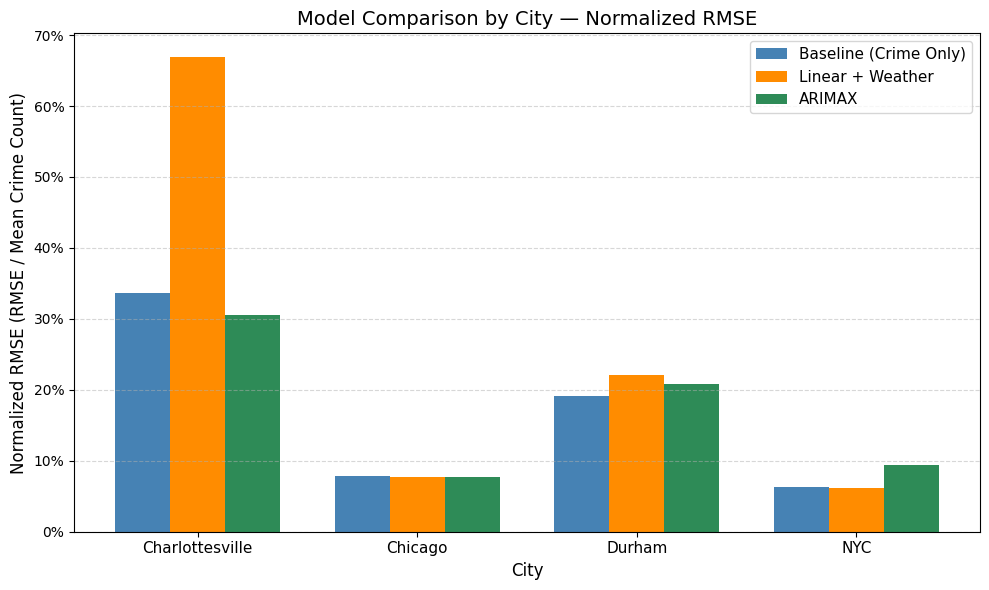

In [18]:
# Build unified results table
city_results_full = city_results.merge(arimax_df, on='city')

# Add mean actuals for NRMSE normalization
mean_actuals = (
    test.groupby('city')['total_crime_count'].mean().reset_index()
    .rename(columns={'total_crime_count': 'mean_actuals'})
)
city_results_full = city_results_full.merge(mean_actuals, on='city')

# Compute NRMSE for all three models
city_results_full['nrmse_baseline'] = city_results_full['baseline_rmse'] / city_results_full['mean_actuals']
city_results_full['nrmse_weather']  = city_results_full['weather_rmse']  / city_results_full['mean_actuals']
city_results_full['nrmse_arimax']   = city_results_full['arimax_rmse']   / city_results_full['mean_actuals']

print(city_results_full[['city','nrmse_baseline','nrmse_weather','nrmse_arimax']])

# Plot
cities = city_results_full['city']
x = np.arange(len(cities))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, city_results_full['nrmse_baseline'], width, label='Baseline (Crime Only)', color='steelblue')
bars2 = ax.bar(x,         city_results_full['nrmse_weather'],  width, label='Linear + Weather',      color='darkorange')
bars3 = ax.bar(x + width, city_results_full['nrmse_arimax'],   width, label='ARIMAX',                color='seagreen')

ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Normalized RMSE (RMSE / Mean Crime Count)', fontsize=12)
ax.set_title('Model Comparison by City — Normalized RMSE', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cities, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nrmse_comparison.png', dpi=150)
plt.show()

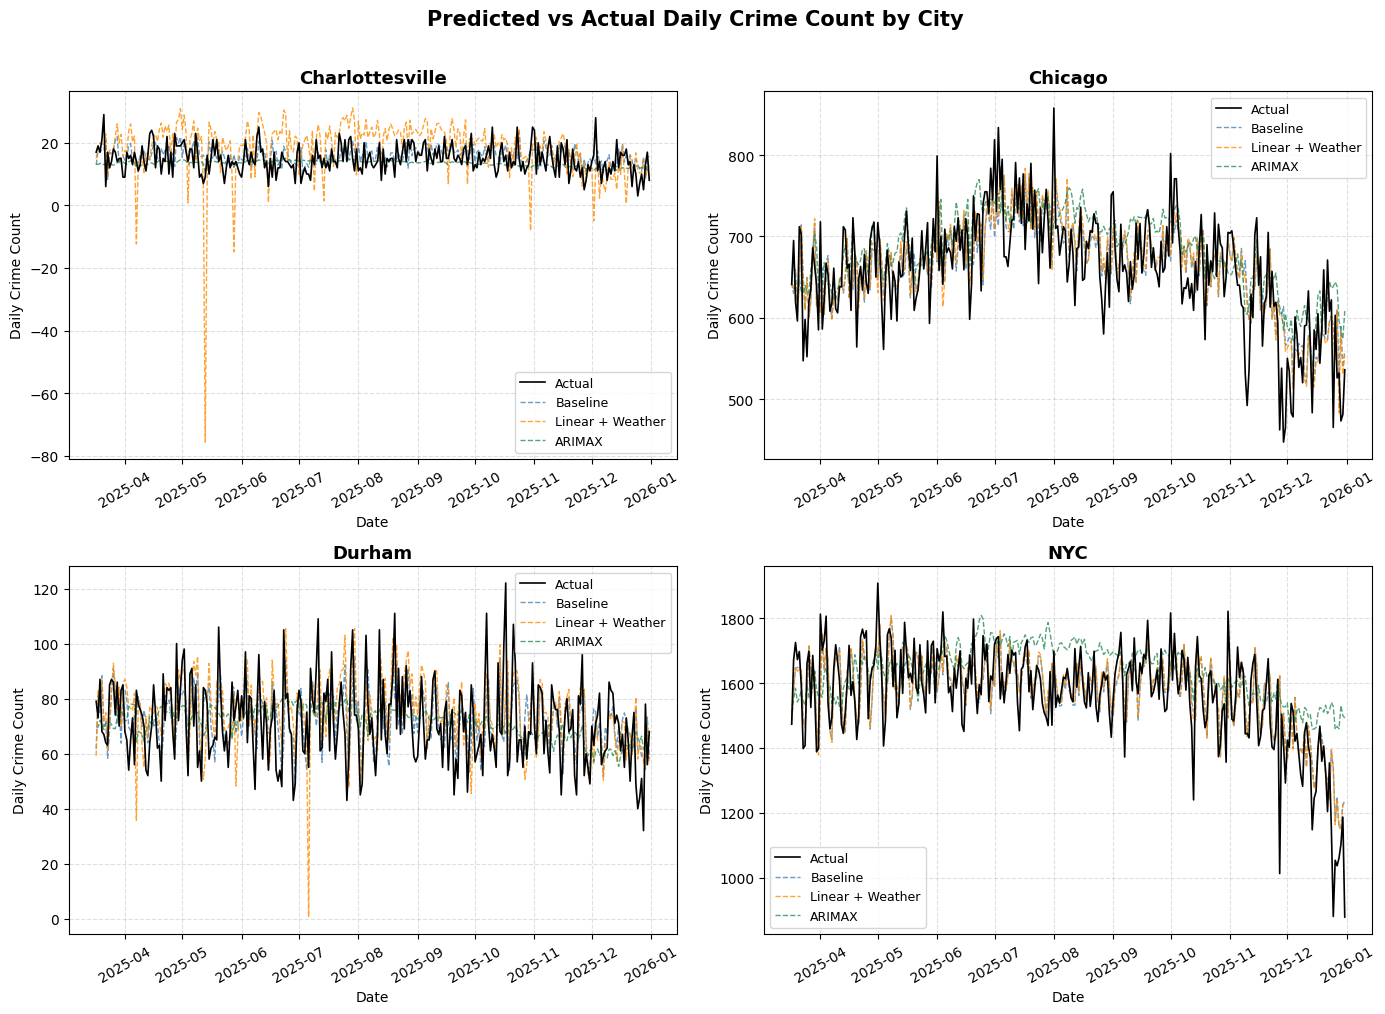

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, city in enumerate(city_results_full['city']):
    ax = axes[idx]
    
    # Get actuals and linear model preds from test
    city_test = test[test['city'] == city].copy()
    city_test = city_test.sort_values('date')
    
    # Get ARIMAX preds from arimax_results
    arimax_entry = next(r for r in arimax_results if r['city'] == city)
    arimax_preds = arimax_entry['preds']
    
    ax.plot(city_test['date'], city_test['total_crime_count'],
            color='black', linewidth=1.2, label='Actual', zorder=3)
    ax.plot(city_test['date'], city_test['baseline_pred'],
            color='steelblue', linewidth=1, linestyle='--', label='Baseline', alpha=0.8)
    ax.plot(city_test['date'], city_test['weather_pred'],
            color='darkorange', linewidth=1, linestyle='--', label='Linear + Weather', alpha=0.8)
    ax.plot(arimax_preds.index, arimax_preds.values,
            color='seagreen', linewidth=1, linestyle='--', label='ARIMAX', alpha=0.8)
    
    ax.set_title(city, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Daily Crime Count', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)

fig.suptitle('Predicted vs Actual Daily Crime Count by City', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

# Weather + Crime RNN


Processing city: Charlottesville


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MAE: 3.34, RMSE: 4.26, R²: 0.022


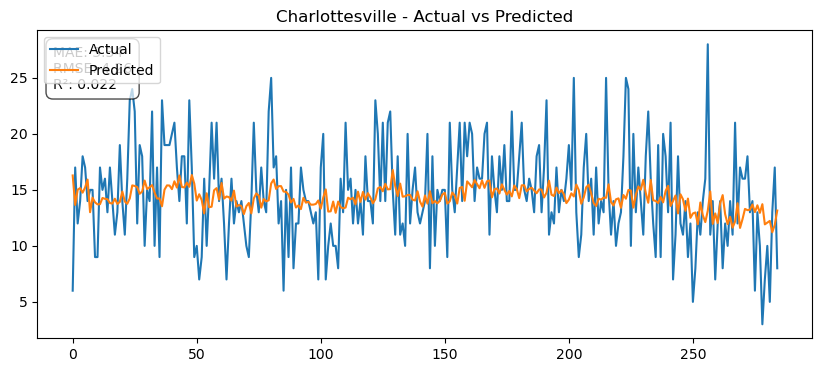


Processing city: Chicago


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
MAE: 47.56, RMSE: 59.40, R²: 0.253


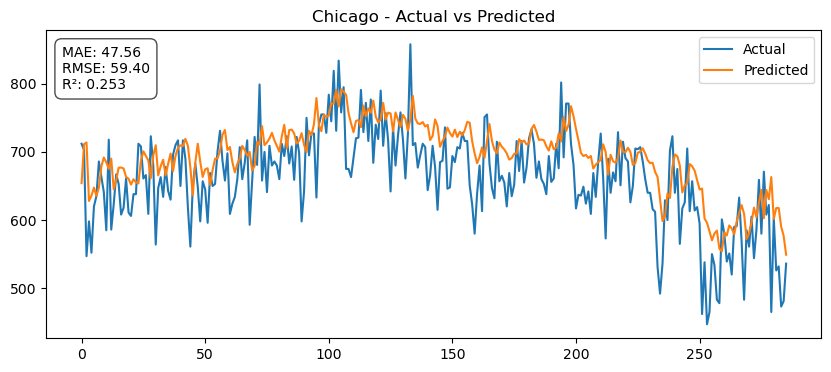


Processing city: Durham


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
MAE: 10.52, RMSE: 13.61, R²: 0.136


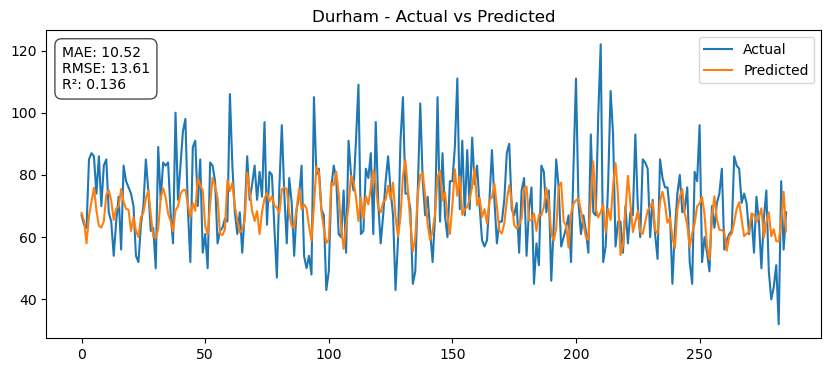


Processing city: NYC


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MAE: 74.64, RMSE: 103.98, R²: 0.544


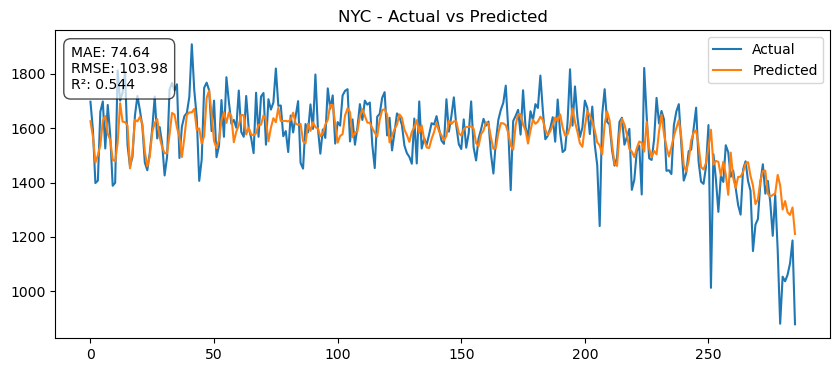


Overall Performance:
MAE     34.013521
RMSE    45.311580
R2       0.238942
dtype: float64

Per-City Results:
              city        MAE        RMSE        R2
0  Charlottesville   3.344824    4.258894  0.022487
1          Chicago  47.557486   59.404780  0.253456
2           Durham  10.515375   13.606187  0.135760
3              NYC  74.636398  103.976458  0.544065


In [83]:
import os
# to help reproducability
import random
random.seed(42)
import numpy as np
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = str(42)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import tensorflow as tf
tf.random.set_seed(42)
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
import matplotlib.pyplot as plt

# original features
features = ['total_crime_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']

# load data
df = pd.read_csv("weather_crime_final.csv")
df['date'] = pd.to_datetime(df['date'])

# lag the weather 1 day, drop nans caused by lag
df[f'temp_lag'] = df['Daily Temperature Mean'].shift(1)
df[f'precip_lag'] = df['Daily Precipitation Sum'].shift(1)
df = df.dropna().reset_index(drop=True)

features = ['total_crime_count', 'temp_lag', 'precip_lag']

# helper functions
# create time sequences for RNN
def create_sequences(data, target_idx, seq_length=14):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_idx])
    return np.array(X), np.array(y)

# build the RNN model
def build_model(input_shape):
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# convert scaled predictions back to original values
def inverse_transform(preds, scaler, target_idx, n_features):
    temp = np.zeros((len(preds), n_features))
    temp[:, target_idx] = preds.flatten()
    return scaler.inverse_transform(temp)[:, target_idx]

# evaluate model performance
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# process each city 
def process_city(city_df):
    # train test split
    split = int(len(city_df) * 0.8)
    train, test = city_df.iloc[:split], city_df.iloc[split:]

    # scale features using MinMaxScaler
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[features])
    test_scaled = scaler.transform(test[features])

    # create sequences for RNN input
    target_idx = features.index('total_crime_count')
    X_train, y_train = create_sequences(train_scaled, target_idx, seq_length=SEQ_LENGTH)
    X_test, y_test = create_sequences(test_scaled, target_idx, seq_length=SEQ_LENGTH)

    # build and train model
    model = build_model((SEQ_LENGTH, len(features)))
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        shuffle=False,
        verbose=0
    )

    # make predictions, convert them back to original scale, and evaluate them
    y_pred = model.predict(X_test)
    y_pred_inv = inverse_transform(y_pred, scaler, target_idx, len(features))
    y_test_inv = inverse_transform(y_test.reshape(-1, 1), scaler, target_idx, len(features))
    metrics = evaluate(y_test_inv, y_pred_inv)
    
    return metrics, y_test_inv, y_pred_inv

results = []
for city, city_df in df.groupby('city'):
    print(f"\nProcessing city: {city}")
    metrics, y_true, y_pred = process_city(city_df)
    print(f"MAE: {metrics['MAE']:.2f}, RMSE: {metrics['RMSE']:.2f}, R²: {metrics['R2']:.3f}")
    results.append({"city": city, **metrics})

    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(f"{city} - Actual vs Predicted")
    plt.legend()
    
    # add metrics on the plot
    metric_text = f"MAE: {metrics['MAE']:.2f}\nRMSE: {metrics['RMSE']:.2f}\nR²: {metrics['R2']:.3f}"
    plt.text(
        0.02, 0.95, metric_text,
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
    )

    # save figure
    plt.savefig(f"Outputs/{city}weather_crime.png", bbox_inches='tight')
    plt.show()

# results
results_df = pd.DataFrame(results)
print("\nOverall Performance:")
print(results_df.mean(numeric_only=True))
print("\nPer-City Results:")
print(results_df)

# Crime only RNN


Processing city: Charlottesville


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
MAE: 3.47, RMSE: 4.36, R²: 0.008


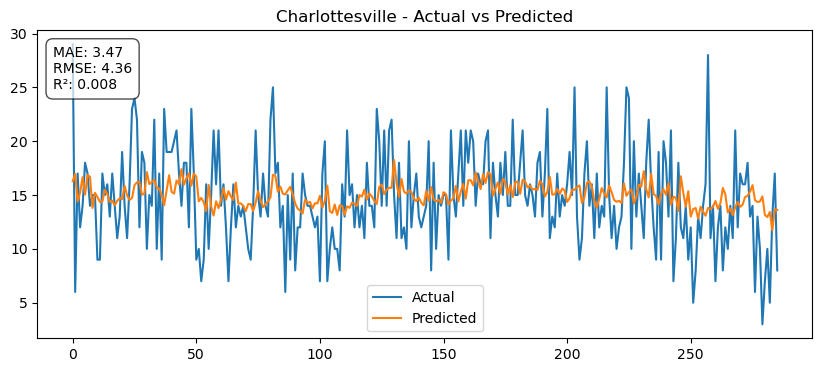


Processing city: Chicago


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
MAE: 41.84, RMSE: 52.71, R²: 0.412


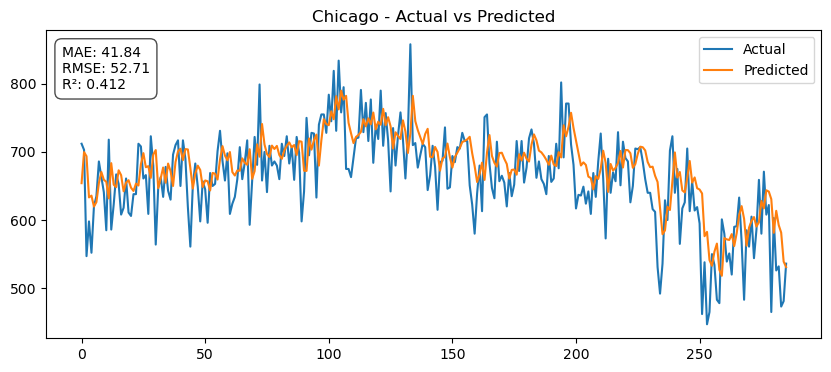


Processing city: Durham


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
MAE: 10.57, RMSE: 13.58, R²: 0.139


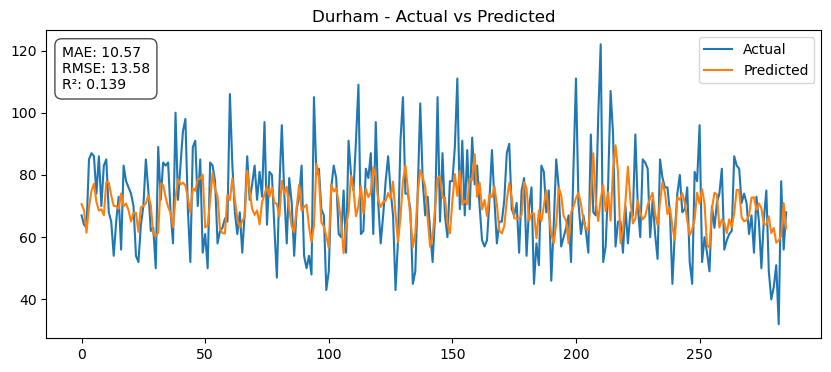


Processing city: NYC


C:\Users\yuanb\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
MAE: 73.63, RMSE: 101.62, R²: 0.565


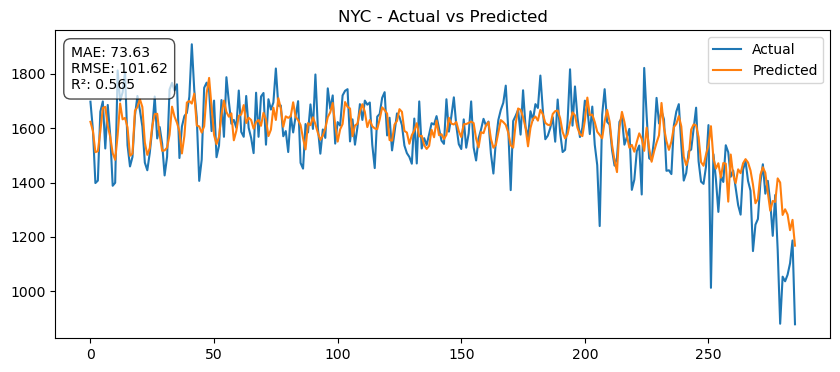


Overall Performance:
MAE     32.374255
RMSE    43.069303
R2       0.280851
dtype: float64

Per-City Results:
              city        MAE        RMSE        R2
0  Charlottesville   3.466445    4.364785  0.008018
1          Chicago  41.835022   52.714244  0.412147
2           Durham  10.565873   13.583034  0.138699
3              NYC  73.629681  101.615150  0.564538


In [82]:
features = ['total_crime_count']
# load data
df = pd.read_csv("weather_crime_final.csv")
df['date'] = pd.to_datetime(df['date'])

# helper functions
# create time sequences for RNN
def create_sequences(data, target_idx, seq_length=7):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_idx])
    return np.array(X), np.array(y)

# build the RNN model
def build_model(input_shape):
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# convert scaled predictions back to original values
def inverse_transform(preds, scaler, target_idx, n_features):
    temp = np.zeros((len(preds), n_features))
    temp[:, target_idx] = preds.flatten()
    return scaler.inverse_transform(temp)[:, target_idx]

# evaluate model performance
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# process each city 
def process_city(city_df):
    # train test split
    split = int(len(city_df) * 0.8)
    train, test = city_df.iloc[:split], city_df.iloc[split:]

    # scale features using MinMaxScaler
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train[features])
    test_scaled = scaler.transform(test[features])

    # create sequences for RNN input
    target_idx = features.index('total_crime_count')
    X_train, y_train = create_sequences(train_scaled, target_idx)
    X_test, y_test = create_sequences(test_scaled, target_idx)

    # build and train model
    model = build_model((SEQ_LENGTH, len(features)))
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        shuffle=False,
        verbose=0
    )

    # make predictions, convert them back to original scale, and evaluate them
    y_pred = model.predict(X_test)
    y_pred_inv = inverse_transform(y_pred, scaler, target_idx, len(features))
    y_test_inv = inverse_transform(y_test.reshape(-1, 1), scaler, target_idx, len(features))
    metrics = evaluate(y_test_inv, y_pred_inv)
    
    return metrics, y_test_inv, y_pred_inv


results = []
for city, city_df in df.groupby('city'):
    print(f"\nProcessing city: {city}")
    metrics, y_true, y_pred = process_city(city_df)
    print(f"MAE: {metrics['MAE']:.2f}, RMSE: {metrics['RMSE']:.2f}, R²: {metrics['R2']:.3f}")
    results.append({"city": city, **metrics})

    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(f"{city} - Actual vs Predicted")
    plt.legend()
    
    # add metrics on the plot
    metric_text = f"MAE: {metrics['MAE']:.2f}\nRMSE: {metrics['RMSE']:.2f}\nR²: {metrics['R2']:.3f}"
    plt.text(
        0.02, 0.95, metric_text,
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
    )

    # save figure
    plt.savefig(f"Outputs/{city}crime_only.png", bbox_inches='tight')
    plt.show()

# results
results_df = pd.DataFrame(results)
print("\nOverall Performance:")
print(results_df.mean(numeric_only=True))
print("\nPer-City Results:")
print(results_df)

Setup + preprocessing

In [3]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Data/weather_crime_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city', 'date'])

Sequence builder

In [4]:
def make_sequences(data, target_col=0, seq_len=14):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, target_col])
    return np.array(X), np.array(y)

LSTM model

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

Better LSTM model

In [41]:
class BetterLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            dropout=0.3,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

Training function

In [6]:
def train_model(X_train, y_train, input_size, epochs=30):
    model = LSTMModel(input_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X = torch.tensor(X_train, dtype=torch.float32)
    y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

    return model

MODEL 1: CRIME ONLY

Running Charlottesville


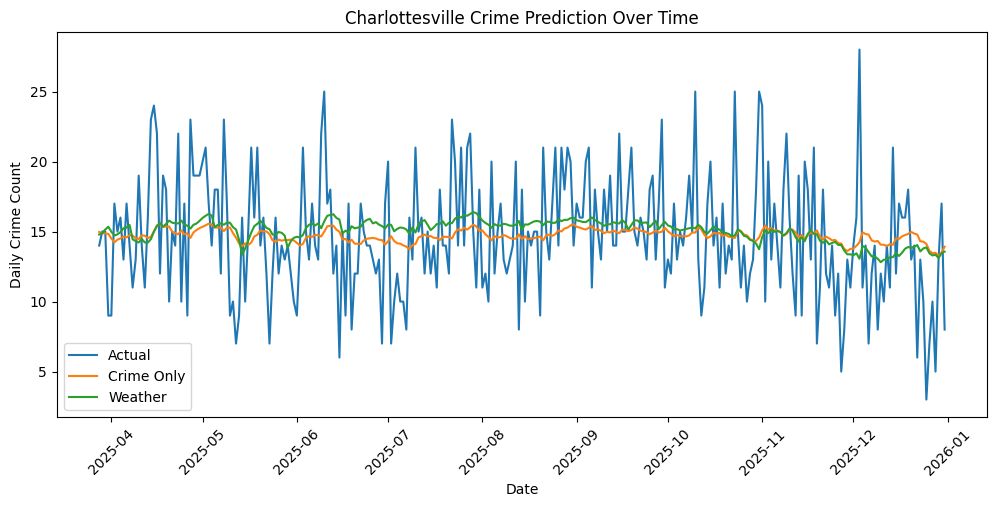

Running Chicago


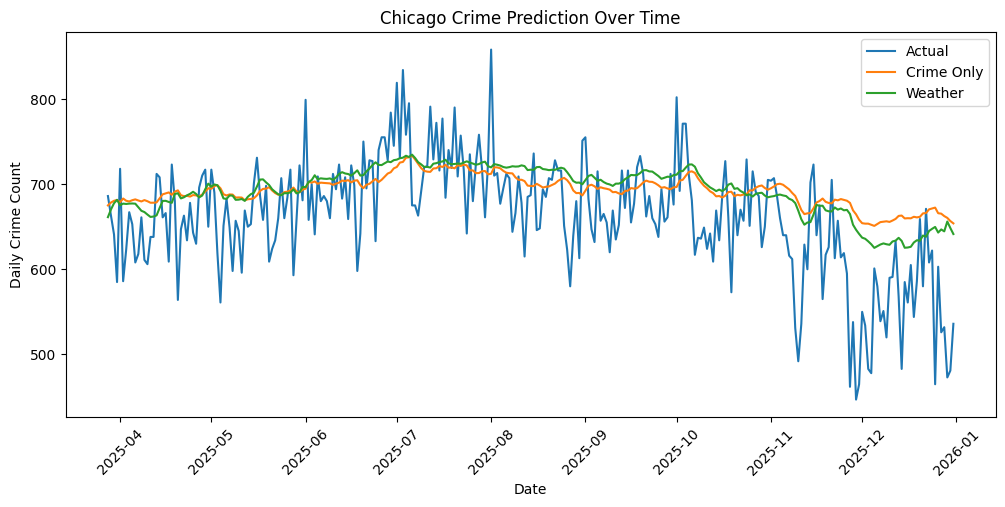

Running Durham


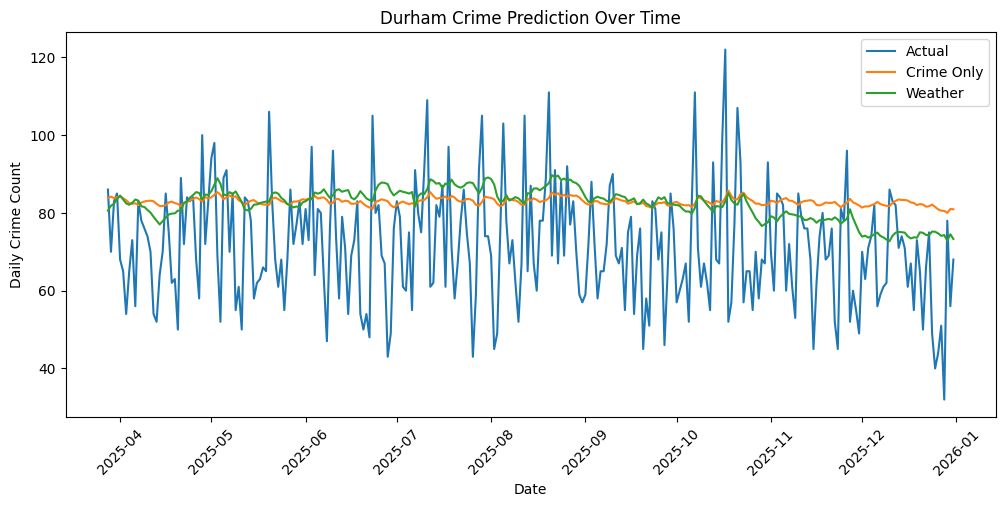

Running NYC


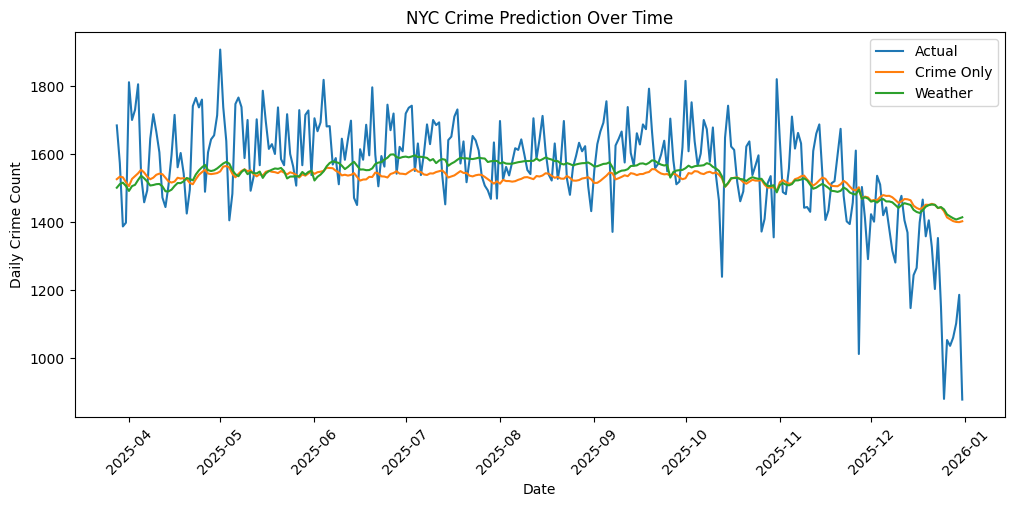

In [ ]:
results = []
cities = df['city'].unique()

for city in cities:
    print(f"Running {city}")
    
    sub = df[df.city == city].copy()
    sub = sub.sort_values("date")

    dates = sub['date'].values

    crime = sub[['total_crime_count']].values

    scaler = StandardScaler()
    crime_scaled = scaler.fit_transform(crime)

    split = int(len(crime_scaled) * 0.8)

    train = crime_scaled[:split]
    test = crime_scaled[split:]

    X_train, y_train = make_sequences(train)
    X_test, y_test = make_sequences(test)

    model1 = train_model(X_train, y_train, input_size=1)

    with torch.no_grad():
        pred1 = model1(torch.tensor(X_test, dtype=torch.float32)).numpy()

    pred1 = scaler.inverse_transform(pred1)
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

    rmse1 = np.sqrt(mean_squared_error(y_test_real, pred1))



    features = ['total_crime_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']
    data = sub[features].values

    scaler2 = StandardScaler()
    data_scaled = scaler2.fit_transform(data)

    train = data_scaled[:split]
    test = data_scaled[split:]

    X_train2, y_train2 = make_sequences(train, target_col=0)
    X_test2, y_test2 = make_sequences(test, target_col=0)

    model2 = train_model(X_train2, y_train2, input_size=3)

    with torch.no_grad():
        pred2 = model2(torch.tensor(X_test2, dtype=torch.float32)).numpy()

    mean = scaler2.mean_[0]
    scale = scaler2.scale_[0]

    pred2 = pred2 * scale + mean
    y_test2 = y_test2 * scale + mean

    rmse2 = np.sqrt(mean_squared_error(y_test2, pred2))


    test_dates = dates[split:][14:]  


    plt.figure(figsize=(12,5))

    plt.plot(test_dates, y_test_real, label="Actual")
    plt.plot(test_dates, pred1, label="Crime Only")
    plt.plot(test_dates, pred2, label="Weather")

    plt.title(f"{city} Crime Prediction Over Time")
    plt.xlabel("Date")
    plt.ylabel("Daily Crime Count")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    results.append({
        "city": city,
        "crime_only_rmse": rmse1,
        "weather_rmse": rmse2
    })

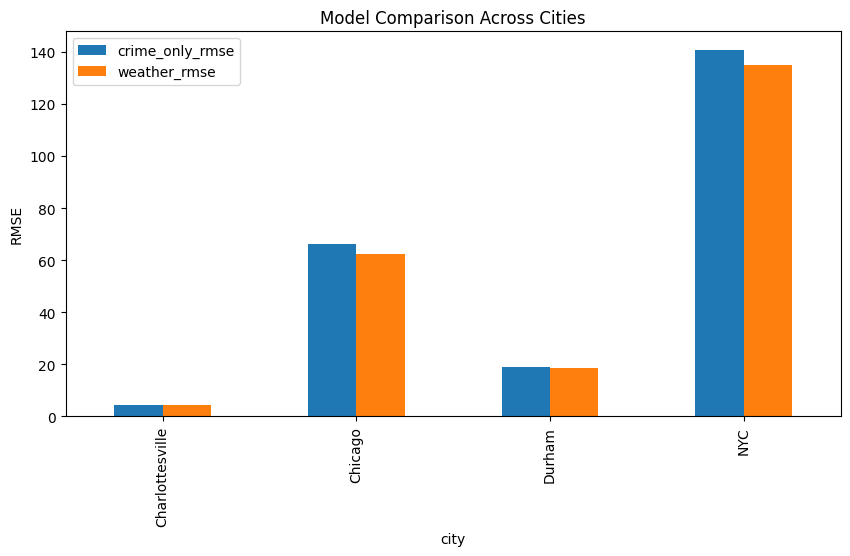

In [18]:
results_df = pd.DataFrame(results)

results_df.set_index("city").plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison Across Cities")
plt.ylabel("RMSE")
plt.show()

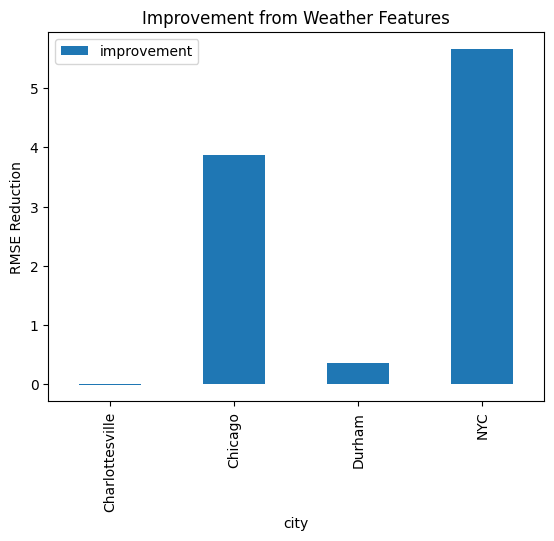

In [19]:
results_df["improvement"] = results_df["crime_only_rmse"] - results_df["weather_rmse"]

results_df.plot(x="city", y="improvement", kind="bar")
plt.title("Improvement from Weather Features")
plt.ylabel("RMSE Reduction")
plt.show()

In [39]:
def train_model1(X_train, y_train, input_size, epochs=100):
    model = BetterLSTM(input_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X = torch.tensor(X_train, dtype=torch.float32)
    y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

    return model

Running Charlottesville


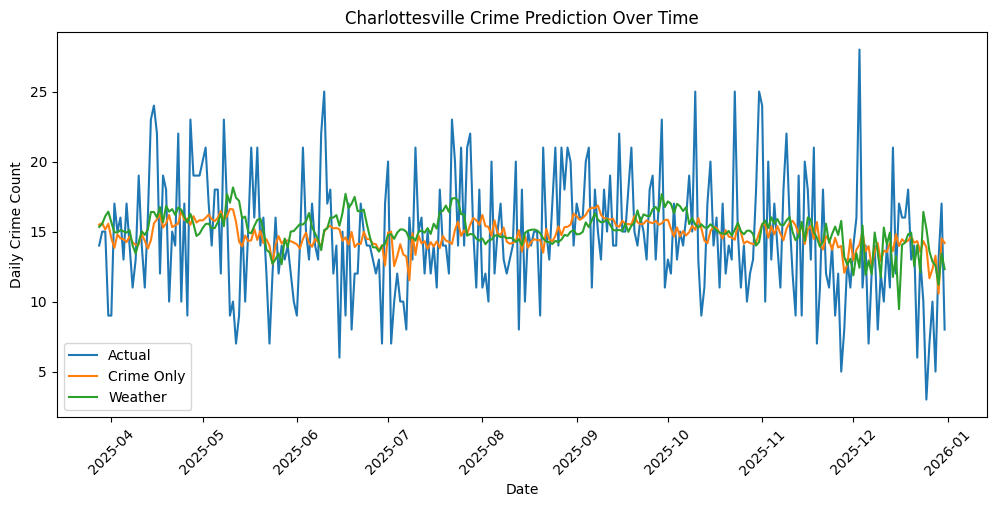

Running Chicago


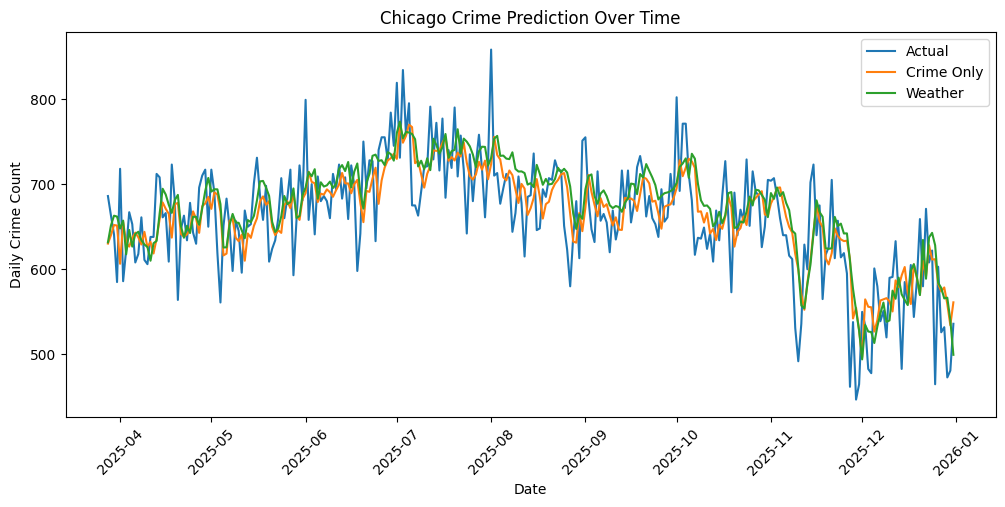

Running Durham


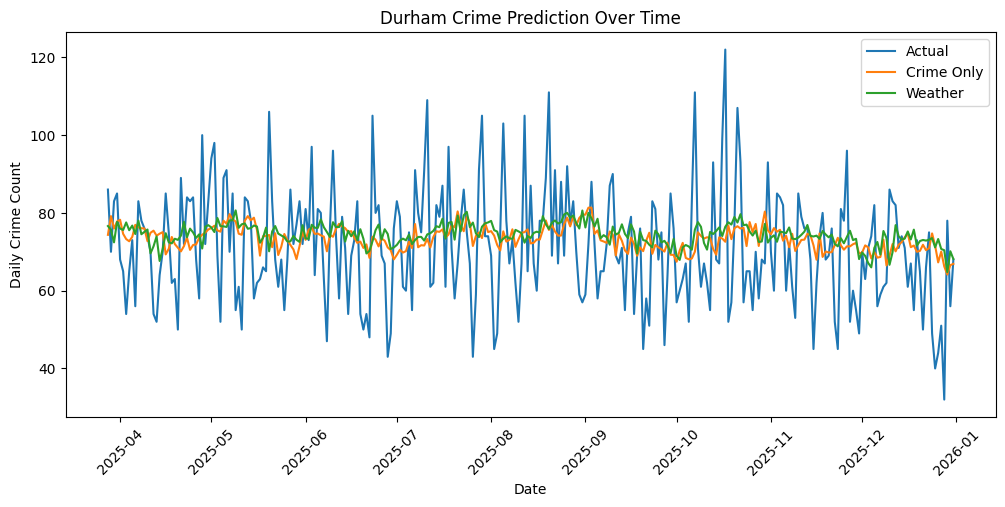

Running NYC


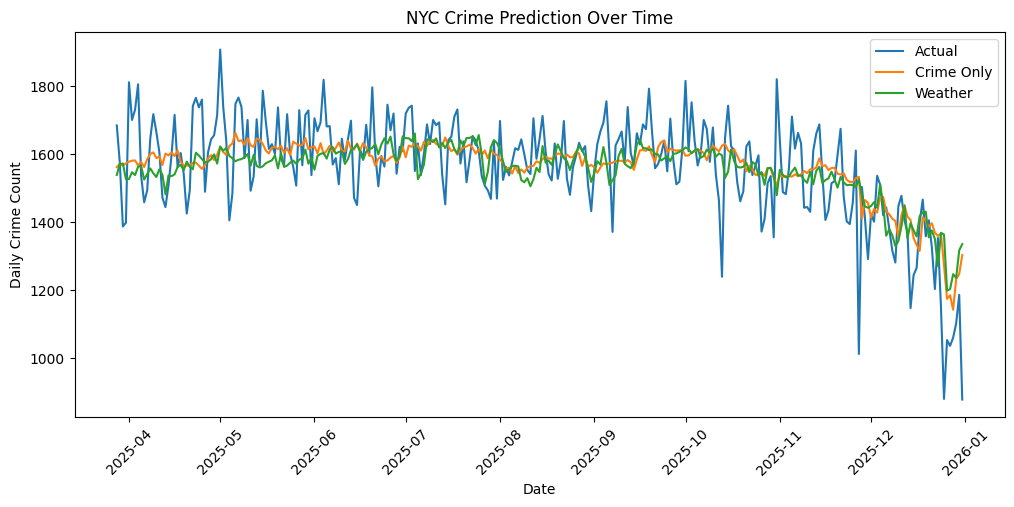

In [42]:
results = []
cities = df['city'].unique()

for city in cities:
    print(f"Running {city}")
    
    sub = df[df.city == city].copy()
    sub = sub.sort_values("date")

    dates = sub['date'].values

    crime = sub[['total_crime_count']].values

    scaler = StandardScaler()
    crime_scaled = scaler.fit_transform(crime)

    split = int(len(crime_scaled) * 0.8)

    train = crime_scaled[:split]
    test = crime_scaled[split:]

    X_train, y_train = make_sequences(train)
    X_test, y_test = make_sequences(test)

    model1 = train_model1(X_train, y_train, input_size=1)

    with torch.no_grad():
        pred1 = model1(torch.tensor(X_test, dtype=torch.float32)).numpy()

    pred1 = scaler.inverse_transform(pred1)
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

    rmse1 = np.sqrt(mean_squared_error(y_test_real, pred1))



    features = ['total_crime_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']
    data = sub[features].values

    scaler2 = StandardScaler()
    data_scaled = scaler2.fit_transform(data)

    train = data_scaled[:split]
    test = data_scaled[split:]

    X_train2, y_train2 = make_sequences(train, target_col=0)
    X_test2, y_test2 = make_sequences(test, target_col=0)

    model2 = train_model1(X_train2, y_train2, input_size=3)

    with torch.no_grad():
        pred2 = model2(torch.tensor(X_test2, dtype=torch.float32)).numpy()

    mean = scaler2.mean_[0]
    scale = scaler2.scale_[0]

    pred2 = pred2 * scale + mean
    y_test2 = y_test2 * scale + mean

    rmse2 = np.sqrt(mean_squared_error(y_test2, pred2))


    test_dates = dates[split:][14:]  


    plt.figure(figsize=(12,5))

    plt.plot(test_dates, y_test_real, label="Actual")
    plt.plot(test_dates, pred1, label="Crime Only")
    plt.plot(test_dates, pred2, label="Weather")

    plt.title(f"{city} Crime Prediction Over Time")
    plt.xlabel("Date")
    plt.ylabel("Daily Crime Count")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    results.append({
        "city": city,
        "crime_only_rmse": rmse1,
        "weather_rmse": rmse2
    })

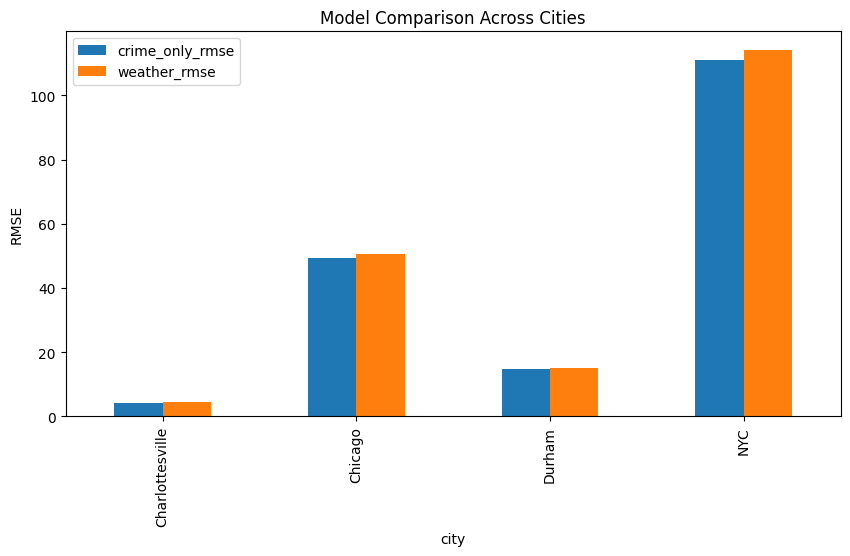

In [43]:
results_df = pd.DataFrame(results)

results_df.set_index("city").plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison Across Cities")
plt.ylabel("RMSE")
plt.show()

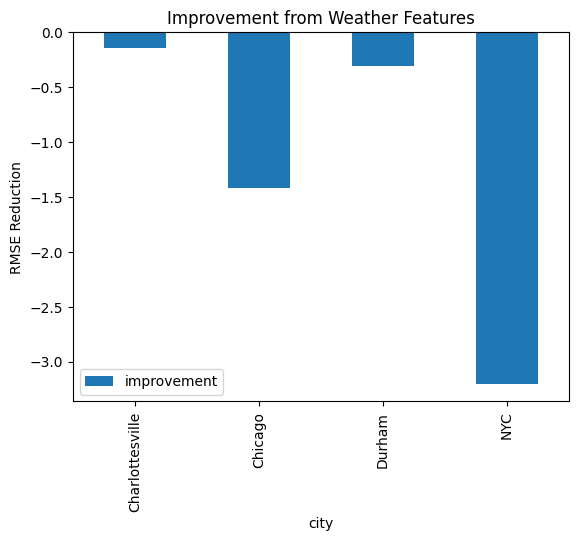

In [44]:
results_df["improvement"] = results_df["crime_only_rmse"] - results_df["weather_rmse"]

results_df.plot(x="city", y="improvement", kind="bar")
plt.title("Improvement from Weather Features")
plt.ylabel("RMSE Reduction")
plt.show()